In [2]:
import pandas as pd

df = pd.DataFrame({
    "Hours": [1,2,3,4,5,6,7,8,2,6],
    "Sleep": [8,7,6,6,5,5,4,4,7,5],
    "Score": [50,55,60,65,70,75,80,85,58,78]
})

In [3]:
print(df.isnull().sum())
print(df.describe())

Hours    0
Sleep    0
Score    0
dtype: int64
           Hours      Sleep      Score
count  10.000000  10.000000  10.000000
mean    4.400000   5.700000  67.600000
std     2.366432   1.337494  11.786998
min     1.000000   4.000000  50.000000
25%     2.250000   5.000000  58.500000
50%     4.500000   5.500000  67.500000
75%     6.000000   6.750000  77.250000
max     8.000000   8.000000  85.000000


In [4]:
df["Efficiency"] = df["Score"] / df["Hours"]
df["Sleep_Impact"] = df["Score"] / df["Sleep"]
df["Study_Intensity"] = df["Hours"] / df["Sleep"]

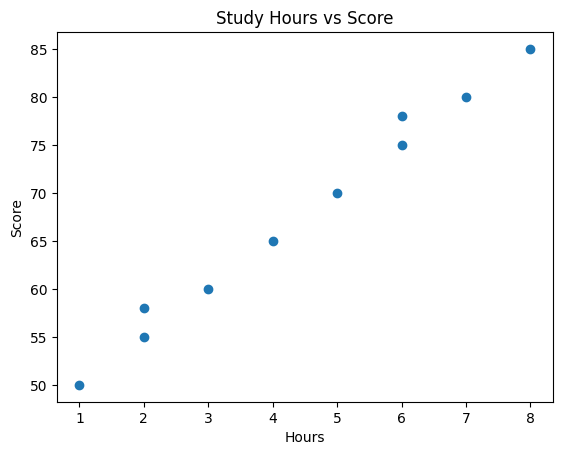

In [5]:
import matplotlib.pyplot as plt

plt.scatter(df["Hours"], df["Score"])
plt.xlabel("Hours")
plt.ylabel("Score")
plt.title("Study Hours vs Score")
plt.show()

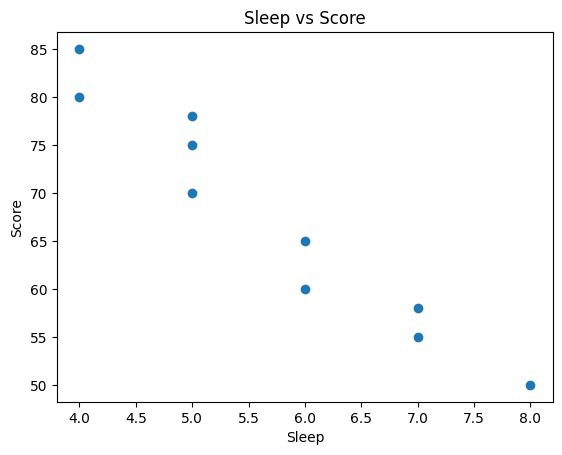

In [6]:
plt.scatter(df["Sleep"], df["Score"])
plt.xlabel("Sleep")
plt.ylabel("Score")
plt.title("Sleep vs Score")
plt.show()

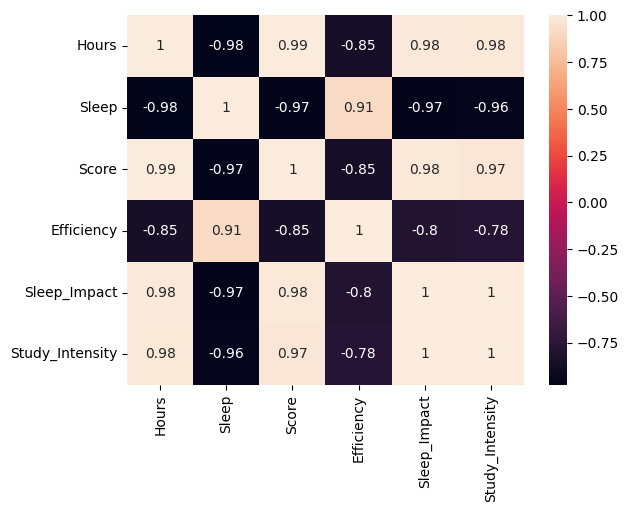

In [7]:
import seaborn as sns

sns.heatmap(df.corr(), annot=True)
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[["Hours", "Sleep", "Efficiency", "Sleep_Impact", "Study_Intensity"]]
y = df["Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

In [9]:
from sklearn.metrics import mean_absolute_error

print("Error:", mean_absolute_error(y_test, pred))

Error: 0.5429221282416918


- More study hours → higher score
- Sleep affects performance
- Feature engineering improves model accuracy

In [12]:
df.to_csv("../data/dataset.csv", index=False)